Colab Version

In [1]:
pip install uv

Note: you may need to restart the kernel to use updated packages.


In [2]:
!uv pip install opencv-python
!uv pip install yolov5
!uv pip install numba
!uv pip install numpy==1.24.0
!uv pip install torch>=1.7.1
!uv pip install matplotlib
!uv pip install requests
!uv pip install pandas
!uv pip install torchvision
!uv pip install torchtnt

Audited 1 package in 5ms
Audited 1 package in 8ms
Audited 1 package in 1ms
Audited 1 package in 1ms
zsh:1: 1.7.1 not found
Audited 1 package in 2ms
Audited 1 package in 2ms
Audited 1 package in 3ms
Audited 1 package in 3ms
Audited 1 package in 4ms


In [3]:
!git clone https://github.com/xHascox/Adversarial-Patch-ART.git

fatal: destination path 'Adversarial-Patch-ART' already exists and is not an empty directory.


In [4]:
!git clone https://github.com/xHascox/adversarial-robustness-toolbox.git

fatal: destination path 'adversarial-robustness-toolbox' already exists and is not an empty directory.


# Adversarial Patch Generation - Collusion

This notebook uses a given dataset to generate an adversarial patch which is classified as a chosen class.

## Environment

ART should be compatible with Python 3.9, 3.10 and 3.11 (https://github.com/Trusted-AI/adversarial-robustness-toolbox)

We install ART using the flag -e so we can use our own modified version, which can be cloned from: https://github.com/xHascox/adversarial-robustness-toolbox

In [5]:
!uv pip install -e ./adversarial-robustness-toolbox

Resolved 9 packages in 520ms                                         
   Building adversarial-robustness-toolbox @ file:///home/vortex/Adversarial-Patch-A
   Building adversarial-robustness-toolbox @ file:///home/vortex/Adversarial-Patch-A
      Built adversarial-robustness-toolbox @ file:///home/vortex/Adversarial-Patch-A
Prepared 1 package in 312ms                                              
Uninstalled 1 package in 0.52ms
Installed 1 package in 1msess-toolbox==1.18.2 (from file:///
 ~ adversarial-robustness-toolbox==1.18.2 (from file:///home/vortex/Adversarial-Patch-ART/adversarial-robustness-toolbox)


In [6]:
import site
site.main()

# ART - Adversarial Patch - PyTorch - YOLO

This Notebook is based on: https://github.com/Trusted-AI/adversarial-robustness-toolbox/blob/main/notebooks/adversarial_patch/attack_adversarial_patch_pytorch_yolo.ipynb

**NOTE**: If the following cell fails, restart the session and run again

In [7]:
import art.attacks.evasion
from art.estimators.object_detection.pytorch_yolo import PyTorchYolo
from art.attacks.evasion import AdversarialPatchPyTorch
art.attacks.evasion.__file__  # Making sure we use our version of ART, should be /content/adversarial-robustness-toolbox/art/attacks/evasion/__init__.py

/home/vortex/Adversarial-Patch-ART/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'/home/vortex/Adversarial-Patch-ART/adversarial-robustness-toolbox/art/attacks/evasion/__init__.py'

## Patch Generation

In [8]:
import yolov5
from yolov5.utils.loss import ComputeLoss

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import requests
import io
from io import BytesIO
import zipfile

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch
import torchvision
from torchvision.transforms import transforms
from tqdm import tqdm
from PIL import Image

import cv2
import matplotlib
import matplotlib.pyplot as plt


plt.style.use('ggplot')
matplotlib.use('Agg')  # Use the 'Agg' backend for headless mode

#matplotlib.use( 'tkagg' )
%matplotlib inline

/home/vortex/Adversarial-Patch-ART/.venv/lib/python3.10/site-packages/yolov5/utils/general.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


Yolov5 classes etc.: https://github.com/ultralytics/yolov5/blob/master/data/coco.yaml

In [9]:
OBJECT_CATEGORY_NAMES = ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
        'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
        'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
        'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
        'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
        'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
        'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
        'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors',
        'teddy bear', 'hair drier', 'toothbrush']  # These are the classes that Yolov5 can detect

In [10]:
OBJECT_CATEGORY_NAMES.index("car")

2

In [11]:
import pickle
# Function to load data
def load_data(file_path):
    with open(file_path, 'rb') as f:
        return pickle.load(f)

# Function to save data
def save_data(file_path, data):
    with open(file_path, 'wb') as f:
        pickle.dump(data, f)

In [12]:
def extract_predictions(predictions_, conf_thresh=0, n_boxes=5, classes=[], DEBUG=False):
    """
    Filters the predictions obtained from a model by their confidence and classes

    predictions_: The predictions from a model
    conf_thresh: Min. score for predictions to be included (float)
    n_boxes: Max. number of prediction to keep (takes the ones with highest score) (int)
    classes: classes to keep (all if empty) (list)

    Returns a tuple of (classes, boxes, scores) of the detections
    """

    # Filter by confidence threshold
    boxes = predictions_["boxes"]
    scores = predictions_["scores"]
    labels = predictions_["labels"]

    if DEBUG: print(f">>>> filtering {len(scores)} with threshold {conf_thresh}")
    filtered_indices = [i for i, score in enumerate(scores) if score >= conf_thresh]
    if len(filtered_indices) < 1:
        return [], [], []
    boxes = [boxes[i] for i in filtered_indices]
    scores = [scores[i] for i in filtered_indices]
    labels = [labels[i] for i in filtered_indices]

    # Apply Non-Maximum Suppression (NMS)
    boxes_tensor = torch.tensor(boxes)
    scores_tensor = torch.tensor(scores)
    if DEBUG: print(f">>>> running NMS with {len(scores)} scores")
    keep_indices = torchvision.ops.nms(boxes_tensor, scores_tensor, iou_threshold=0.5).tolist()

    #print(predictions_)

    predictions_class = [OBJECT_CATEGORY_NAMES[i] for i in labels]  # For each prediction, get the predicted class
    predictions_boxes = [[(i[0], i[1]), (i[2], i[3])] for i in boxes]  # Get the predicted bounding boxes
    predictions_score = scores  # Get the prediction score

    predictions_class = [predictions_class[i] for i in keep_indices]
    predictions_boxes = [predictions_boxes[i] for i in keep_indices]
    predictions_score = [predictions_score[i] for i in keep_indices]

    predictions_t = sorted(range(len(predictions_score)), key=lambda i: predictions_score[i], reverse=True)  # Sort the prediction indices by their score

    # Put the other lists in the same order, by descending prediction score
    predictions_boxes = [predictions_boxes[i] for i in predictions_t]
    predictions_class = [predictions_class[i] for i in predictions_t]
    predictions_scores = [predictions_score[i] for i in predictions_t]
    if classes:  # only keep the n_boxes best detections of the specified classes, if they are above the confidence threshold
        predictions_boxes_n = [e for e, c, s in zip(predictions_boxes, predictions_class, predictions_scores) if c in classes and s >= conf_thresh][:n_boxes]
        predictions_class_n = [e for e, s in zip(predictions_class, predictions_scores) if e in classes and s >= conf_thresh][:n_boxes]
        predictions_scores_n = [e for e, c in zip(predictions_scores, predictions_class) if c in classes and e >= conf_thresh][:n_boxes]
    else:  # only keep the n_boxes best detections
        predictions_boxes_n = predictions_boxes[:n_boxes]
        predictions_class_n = predictions_class[:n_boxes]
        predictions_scores_n = predictions_scores[:n_boxes]

    if DEBUG: print(f"predictions_class_n {predictions_class_n}")
    if DEBUG: print(f"predictions_boxes_n {predictions_boxes_n}")
    if DEBUG: print(f"predictions_scores_n {predictions_scores_n}")
    return predictions_class_n, predictions_boxes_n, predictions_scores_n


def plot_image_with_boxes(img, boxes, pred_cls, title, scores, color=(0,255,0), colordict={}, target_boxes=None):
    """
    Visualizes an image with the detected object boxes

    img: Image to plot
    boxes: Prediction boxes (from extract_predictions)
    pred_cls: Class (from extract_predictions)
    title: The plot title (str)
    scores: Score (from extract_predictions)
    color: Default color value for the boxes (tuple)
    colordict: Dictionary with box colors for some classes (dict) like {"car":(255,0,0)}
    """
    text_size = 1
    text_th = 3
    rect_th = 4

    for i in range(len(boxes)):
        if target_boxes is not None:
            #print("target_boxes[i])", target_boxes)
            cv2.rectangle(img, (int(target_boxes[0]), int(target_boxes[1])), (int(target_boxes[2]), int(target_boxes[3])),
                        color=(255,255,0), thickness=rect_th//2)

        cv2.rectangle(img, (int(boxes[i][0][0]), int(boxes[i][0][1])), (int(boxes[i][1][0]), int(boxes[i][1][1])),
                      color=colordict.get(pred_cls[i], color), thickness=rect_th)
        # Write the prediction class
        cv2.putText(img, pred_cls[i]+" "+f"{scores[i]:.2f}", (int(boxes[i][0][0]), int(boxes[i][0][1])), cv2.FONT_HERSHEY_SIMPLEX, text_size,
                    colordict.get(pred_cls[i], color), thickness=text_th)


    plt.figure(dpi=200)
    plt.axis("off")
    plt.title(title)
    plt.imshow(img.astype(np.uint8), interpolation="nearest")



Check available GPU:

In [13]:
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Count: {torch.cuda.device_count()}")
else:
    print("No GPU found.")

GPU Name: NVIDIA RTX 4000 Ada Generation
GPU Count: 1


Define the model to attack

In [14]:
NUMBER_CHANNELS = 3
INPUT_SHAPE = (NUMBER_CHANNELS, 2048, 2048) # For some reason, this only really works for square images, (512, 1024) used to work

In [15]:
yolov5.utils.general.non_max_suppression

<function yolov5.utils.general.non_max_suppression(prediction, conf_thres=0.25, iou_thres=0.45, classes=None, agnostic=False, multi_label=False, labels=(), max_det=300, nm=0)>

In [16]:
# https://github.com/ultralytics/yolov5/issues/13513
%env TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD=1

env: TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD=1


In [17]:
class Yolo(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.model.hyp = {'box': 0.05,
                        'obj': 1.0,
                        'cls': 0.5,
                        'anchor_t': 4.0,
                        'cls_pw': 1.0,
                        'obj_pw': 1.0,
                        'fl_gamma': 0.0
                        }
        self.compute_loss = ComputeLoss(self.model.model.model)

    def forward(self, x, targets=None):
        if self.training:
            #print("self.training is true")
            outputs = self.model.model.model(x)
            loss, loss_items = self.compute_loss(outputs, targets)
            loss_components_dict = {"loss_total": loss}
            loss_components_dict['loss_box'] = loss_items[0]
            loss_components_dict['loss_obj'] = loss_items[1]
            loss_components_dict['loss_cls'] = loss_items[2]
            return loss_components_dict
        else:
            #print("self.training is false")
            #return self.model(x)
            outputs = self.model(x)

            # Apply non-maximum suppression
            # Default NMS settings: conf_thres=0.25, iou_thres=0.45; adjust as needed
            #results = yolov5.utils.general.non_max_suppression(outputs, conf_thres=0.25, iou_thres=0.45)
            return outputs#results

YOLO_MODEL = "./yolov5s.pt"
#YOLO_MODEL = "./yolov5x.pt"
model = yolov5.load(YOLO_MODEL)
#model2 = yolov5.load('best.pt')
#model = torch.hub.load('ultralytics/yolov5', 'custom', 'best.pt')

model = Yolo(model)

detector = PyTorchYolo(model=model,
                    device_type='gpu',
                    input_shape=INPUT_SHAPE,
                    clip_values=(0, 255),
                    attack_losses=("loss_total", "loss_cls",
                                    "loss_box",
                                    "loss_obj"))

Fix the seed

In [18]:
# Set the seed for randomness
seed = 42

# Set the seed for PyTorch
torch.manual_seed(seed)

# If you are using CUDA
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # for all GPUs

# Set the seed for NumPy
np.random.seed(seed)

# Set the seed for Python's built-in random module
random.seed(seed)

### Dataset

**Caution:** when changing the dataset, make sure to delete these files:
- ./preds_orig_person.pickle

To reduce the run time of this notebook, we use these to store deterministic values that are static for an unchanged dataset and take a long time to compute, like object detections on the benign training images filtered for persons.


In [19]:
# directory containing the training images
DATASET_URL_V5 = "https://storage.googleapis.com/weebit-shared/dsv5.zip"
DATASET_V5 = "./datasets/DSV5"

DATASET_URL = DATASET_URL_V5
TRAINING_DATASET_DIR = DATASET_V5

DATASET_CUTOFF_GENERATE = 0
DATASET_CUTOFF = 0

In [20]:
"""
Here, we download the Patch Dataset from remote if it does not already exist on disk, as specified by TRAINING_DATASET_DIR.
"""
# Define the folder and URL
folder_path = TRAINING_DATASET_DIR
zip_url = DATASET_URL

# Check if folder exists
if not os.path.exists(folder_path):
    print(f"{folder_path} does not exist. Downloading ZIP from {zip_url}...")

    # Stream the download and write to a file
    with requests.get(zip_url, stream=True) as response:
        response.raise_for_status()  # Check for HTTP errors
        total_size = int(response.headers.get('content-length', 0))
        chunk_size = 1024 * 1024 * 128 # 128 MB

        # Write to a temp file for large size
        with tqdm(total=total_size//(1024*1024), unit='MB', unit_scale=True, desc='Downloading') as progress_bar:
            temp_zip_path = "temp_download.zip"
            with open(temp_zip_path, 'wb') as file:
                for chunk in response.iter_content(chunk_size=chunk_size):
                    if chunk:  # Filter out keep-alive chunks
                        file.write(chunk)
                        progress_bar.update(len(chunk)//(1024*1024))


    # Now extract the ZIP file
    print("Extracting the files...")
    with zipfile.ZipFile(temp_zip_path, 'r') as zip_ref:
        zip_ref.extractall(folder_path)

    # Optionally remove the zip file after extraction
    os.remove(temp_zip_path)
    print(f"Content extracted to {folder_path}.")
else:
    print(f"{folder_path} already exists. No need to download.")

./datasets/DSV5 already exists. No need to download.


In [21]:
def filter_boxes(predictions, conf_thresh): # TODO WHY IS THIS NEEDED?
    dictionary = {}

    boxes_list = []
    scores_list = []
    labels_list = []

    for i in range(len(predictions[0]["boxes"])):
        score = predictions[0]["scores"][i]
        if score >= conf_thresh:
            boxes_list.append(predictions[0]["boxes"][i])
            scores_list.append(predictions[0]["scores"][[i]])
            labels_list.append(predictions[0]["labels"][[i]])

    #dictionary["boxes"] = np.vstack(boxes_list)
    if boxes_list:  # Check if boxes_list is not empty
        dictionary["boxes"] = np.vstack(boxes_list)
        dictionary["scores"] = np.hstack(scores_list)
        dictionary["labels"] = np.hstack(labels_list)
    else:
        dictionary["boxes"] = np.empty((0,))  # Assign an empty array if boxes_list is empty
        dictionary["scores"] = np.empty((0,))
        dictionary["labels"] = np.empty((0,))

    y = [dictionary]

    return y

In [22]:
import warnings

# Ignore all future warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# Reason:
# Adversarial-Patch-ART\.venv\Lib\site-packages\yolov5\models\common.py:682: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
#  with amp.autocast(autocast):

urls = []

# Iterate over all files and directories in the given path
for root, dirs, files in os.walk(TRAINING_DATASET_DIR):
    for file in files:
        file_path = os.path.join(root, file)
        print(file_path)  # Do something with the file path
        urls+=[file_path]

print("Size of Dataset:", len(urls))

if not DATASET_CUTOFF:
    DATASET_CUTOFF = len(urls)

# Calculate padding, assumes all images in the training set have the same resolution
train_img_height = Image.open(urls[0]).height
padding_top = (INPUT_SHAPE[1] - train_img_height) // 2
padding_bottom = INPUT_SHAPE[1] - train_img_height - padding_top

transform = transforms.Compose([
        #transforms.Resize(INPUT_SHAPE[1], interpolation=transforms.InterpolationMode.BICUBIC),
        #transforms.CenterCrop(INPUT_SHAPE[1]),
        transforms.Pad((0, padding_top, 0, padding_bottom)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x[:3])  # Keep only the first 3 channels (RGB)
    ])
print("###")
print(transform)

def load_and_transform_image(url):
    im = Image.open(url)
    return transform(im).numpy()

def batch_predict(urls, batch_size):
    all_predictions = []
    for i in tqdm(range(0, len(urls), batch_size), desc="Loading, transforming and predicting Batches"):
        batch_urls = urls[i:i + batch_size]
        batch_images = np.array([load_and_transform_image(url) for url in batch_urls])*255
        batch_dets = detector.predict(batch_images)
        all_predictions.extend(batch_dets)
    return all_predictions

sampled_urls = random.sample(urls, DATASET_CUTOFF if DATASET_CUTOFF > 0 and DATASET_CUTOFF <= len(urls) else len(urls))

from sklearn.model_selection import train_test_split

# Use train_test_split to split the data
train_urls, validation_urls = train_test_split(
    sampled_urls, test_size=0.2, random_state=42
)

training_images_for_generation = train_urls

if DATASET_CUTOFF_GENERATE:
    training_images_for_generation = training_images_for_generation[:DATASET_CUTOFF_GENERATE]

print("After cutoff for Generation:", len(training_images_for_generation))

batch_size = 1
dets = batch_predict(training_images_for_generation, batch_size)

torch.cuda.empty_cache()

#dets2 = detector2.predict(coco_images)
filter_threshold = 0.5
#y = [filter_boxes([t], filter_threshold)[0] for t in tqdm(dets, desc=f"Filtering Predictions threshold {filter_threshold}")]

"""
y_stored = "y.pickle"
# Check if the file exists
if os.path.exists(y_stored):
    # Load from disk
    y = load_data(y_stored)
    print("y loaded from ", y_stored)
else:
    # Get data and store to disk for later use
    y = [filter_boxes([t], filter_threshold)[0] for t in tqdm(dets, desc=f"Filtering Predictions threshold {filter_threshold}")]
    save_data(y_stored, y)
    print("Data retrieved and saved to disk:", y_stored)
"""

./datasets/DSV5/dsv5/Town04_040469.png
./datasets/DSV5/dsv5/Town03_038871.png
./datasets/DSV5/dsv5/Town04_040139.png
./datasets/DSV5/dsv5/Town05_041261.png
./datasets/DSV5/dsv5/Town05_041987.png
./datasets/DSV5/dsv5/Town03_038769.png
./datasets/DSV5/dsv5/Town05_041482.png
./datasets/DSV5/dsv5/Town04_040441.png
./datasets/DSV5/dsv5/Town05_041490.png
./datasets/DSV5/dsv5/Town01_036227.png
./datasets/DSV5/dsv5/Town05_041177.png
./datasets/DSV5/dsv5/Town04_039308.png
./datasets/DSV5/dsv5/Town05_041494.png
./datasets/DSV5/dsv5/Town04_039422.png
./datasets/DSV5/dsv5/Town04_040163.png
./datasets/DSV5/dsv5/Town01_035755.png
./datasets/DSV5/dsv5/Town04_039644.png
./datasets/DSV5/dsv5/Town04_037045.png
./datasets/DSV5/dsv5/Town03_038823.png
./datasets/DSV5/dsv5/Town02_037812.png
./datasets/DSV5/dsv5/Town04_036983.png
./datasets/DSV5/dsv5/Town05_041754.png
./datasets/DSV5/dsv5/Town04_039314.png
./datasets/DSV5/dsv5/Town04_037023.png
./datasets/DSV5/dsv5/Town02_037782.png
./datasets/DSV5/dsv5/Town

Loading, transforming and predicting Batches: 100%|██████████| 1213/1213 [02:53<00:00,  6.98it/s]


'\ny_stored = "y.pickle"\n# Check if the file exists\nif os.path.exists(y_stored):\n    # Load from disk\n    y = load_data(y_stored)\n    print("y loaded from ", y_stored)\nelse:\n    # Get data and store to disk for later use\n    y = [filter_boxes([t], filter_threshold)[0] for t in tqdm(dets, desc=f"Filtering Predictions threshold {filter_threshold}")]\n    save_data(y_stored, y)\n    print("Data retrieved and saved to disk:", y_stored)\n'

In [23]:

#- boxes [N, 4]: the boxes in [x1, y1, x2, y2] format, with 0 <= x1 < x2 <= W and 0 <= y1 < y2 <= H.

In [24]:
# NOTE: This is a temporary workaround for https://github.com/Trusted-AI/adversarial-robustness-toolbox/issues/2601
def create_detector_model():
    model2 = yolov5.load(YOLO_MODEL)
    model2 = Yolo(model2)
    detector2 = PyTorchYolo(model=model2,
                    device_type='gpu',
                    input_shape=INPUT_SHAPE,
                    clip_values=(0, 255),
                    attack_losses=("loss_total", "loss_cls",
                                    "loss_box",
                                    "loss_obj"))
    return detector2

In [25]:
preds_orig_person_stored = "preds_orig_person.pickle"
# Check if the file exists
if os.path.exists(preds_orig_person_stored):
    # Load from disk
    preds_orig_person = load_data(preds_orig_person_stored)
    print("preds_orig_person loaded from ", preds_orig_person_stored)
else:
    # Get data and store to disk for later use
    preds_orig_person = [extract_predictions(d, 0.1, n_boxes=2, classes=["person"]) for d in tqdm(dets, desc="Getting Person Locations of Training Images")]
    save_data(preds_orig_person_stored, preds_orig_person)
    print("Data retrieved and saved to disk:", preds_orig_person_stored)


preds_orig_person loaded from  preds_orig_person.pickle


Attack Parameters

In [49]:
# Path to the disguise image
DISGUISE_PATH = "./Adversarial-Patch-ART/disguises/apple_split.jpg"
#DISGUISE_PATH = "./Adversarial-Patch-ART/disguises/mountain_1.jpg"
#DISGUISE_PATH = "./Adversarial-Patch-ART/disguises/apple.jpg"
#DISGUISE_PATH = "./Adversarial-Patch-ART/disguises/camellia.jpg"
DISGUISE_PATH = None
disguise_distance_factor = 1/400000

USE_PRETRAINED = None # NOTE Filepath of patch to start from or None, if using a disguise, set USE_PRETRAINED = DISGUISE_PATH
GENERATE = False # NOTE Set to True if you want to generate a new patch, False if you just want to apply a pretrained patch

# NOTE only relevant if GENERATE=False
PATCH_PATH = "./trained patches/patch_as_apple_split_3.png"
PATCH_PATH = "patch_camellia_v5.png"

patch_shape=(3, 512, 512)

# Robustness
rotation_max=20
scale_min=0.015 # NOTE patch size = scale * image_size
scale_max=0.025
distortion_scale_max = 0.4
contrast_min = 0.3
contrast_max = 0.5

# Training
learning_rate=0.01
max_epochs=15
max_steps = 0
batch_size=3 # 2 ~ 12.7 GB VRAM with yolov5s - yolov5x with batch=1 21 GB
optimizer="Adam" # ["pgd", "Adam"]
scheduler = "CosineAnnealingWarmRestarts" # ["CosineAnnealingWarmRestarts", "StepLR"]
decay_rate=1.0
decay_step=max_epochs

patch_locations = preds_orig_person # NOTE: Using this, the patches will be applied on the pedestrians locations

# Collusion
split = False # NOTE: True means we do a collusion attack with two patches by splitting the patch into two parts (left and right)
fixed_location_random_scaling = True # NOTE: True means that the patch is scaled randomly but placed at on pedestrians
fixed_gap = True # NOTE: True means that the right patch is placed at a fixed distance to the left patch, False means that it is placed on the right pedestrian
gap_size = 20 # NOTE: The gap size between the two patches if split=True and fixed_gap = True

# fixed
targeted = True
patch_type="square"
patch_location=None # TODO This does not yet work if True, the scaling fails


Patch Generation

In [50]:
torch.cuda.empty_cache()

In [51]:
if DISGUISE_PATH:
    disguise = np.array(Image.open(DISGUISE_PATH).resize(patch_shape[1:]))
    disguise = disguise.transpose(2,0,1)
else:
    disguise = None

if not GENERATE:
    max_epochs = 1
    max_steps = 1

# This is the target detection, e.g. what we want the detections by the model to look like. Mostly a class with score 1 at the patch location
# NOTE: Currently, this will get overwritten in the generation as we place the patches on the pedestrians
synthetic_y = {'boxes': np.array([[0,0,0,0]], dtype=np.float32), # TODO the box would be based on patch_location and patch_shape
 'scores': np.array([    1], dtype=np.float32),
 'labels': np.array([OBJECT_CATEGORY_NAMES.index("stop sign")])}

pretrained_patch = None
if USE_PRETRAINED:
    pretrained_patch=np.array(Image.open(USE_PRETRAINED).resize(patch_shape[1:]))
    pretrained_patch = pretrained_patch.transpose(2,0,1)


ap = AdversarialPatchPyTorch(estimator=detector, summary_writer=False, patch_type=patch_type, targeted=targeted, verbose=True,
                             rotation_max=rotation_max, scale_min=scale_min, scale_max=scale_max, # Robustness
                             distortion_scale_max=distortion_scale_max, contrast_min = contrast_min, contrast_max = contrast_max, # Robustness
                             optimizer=optimizer, scheduler=scheduler, learning_rate=learning_rate, # Training
                             max_epochs=max_epochs, max_steps=max_steps, batch_size=batch_size, # Training
                             patch_shape=patch_shape,  pretrained_patch=pretrained_patch, # Patch
                             disguise=disguise, disguise_distance_factor=disguise_distance_factor, # Disguise
                             split=split, gap_size=gap_size, fixed_gap=fixed_gap, ) # Collusion

if GENERATE:
    patch, patch_mask, loss = ap.generate(x=training_images_for_generation, 
                                          y=[synthetic_y]*len(training_images_for_generation), 
                                          patch_locations=patch_locations, fixed_location_random_scaling=fixed_location_random_scaling, 
                                          transform=transform, detector_creator=create_detector_model, 
                                          decay_rate=decay_rate, decay_step=decay_step)
else:
    patch, patch_mask, loss = ap.generate(x=training_images_for_generation, 
                                          y=[synthetic_y]*len(training_images_for_generation), 
                                          transform=transform,) # run for 1 step to get patch_mask
    patch=np.array(Image.open(PATCH_PATH)) # load external patch
    patch = patch.transpose(2,0,1)



USING DEVICE: cuda:0


Training Epochs:   0%|          | 0/1 [00:00<?, ?it/s]

Training Steps in Epoch 1/1. Previous Loss: nan LR = 0.010000 Sched BASE LR: 0.010000:   0%|          | 1/405 [00:00<05:32,  1.21it/s]
Training Epochs: 100%|██████████| 1/1 [00:00<00:00,  1.21it/s]


In [52]:
loss_history = []
for epoch in loss:
    loss_history.append(sum(epoch))
loss_history = np.array(loss_history)

Loss per epoch

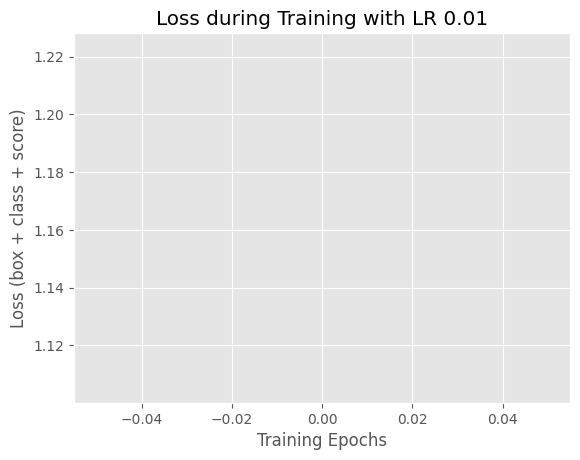

In [53]:
%matplotlib inline
plt.plot(loss_history * (-1 if optimizer=="pgd" else 1))
plt.xlabel("Training Epochs")  # Label the implicit x-axis
plt.ylabel("Loss (box + class + score)")
plt.title(f"Loss during Training with LR {learning_rate}")
plt.show()

In [54]:
flat_loss = [batch_loss for epoch in loss for batch_loss in epoch] # flatten the loss history (it contains loss per patch in a list per epoch)
flat_loss = np.array(flat_loss) * (-1 if optimizer=="pgd" else 1)

# Define the size of the sliding window
k = 10

# Calculate the moving average
moving_averages = np.convolve(flat_loss, np.ones(k)/k, mode='valid')

# Indices for the moving average to align with the input list
average_indices = range(k - 1, len(flat_loss))

Loss per batch

failed to plot avg: x and y must have same first dimension, but have shapes (0,) and (10,)


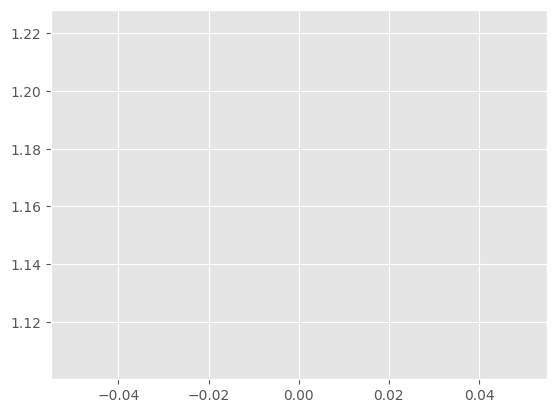

In [55]:
%matplotlib inline
try:
    plt.plot(flat_loss, linewidth=0.5, color=("red"), label="Loss per batch")
    plt.plot(average_indices, moving_averages, linestyle='--', color='blue', linewidth=5, label=f'Moving Average (k={k})')


    plt.xlabel("Training Batches")  # Label the implicit x-axis
    plt.ylabel("Loss (box + class + score + disguise)")
    plt.legend()
    plt.title(f"Loss per batch during training with LR {learning_rate}")
    plt.show()
except Exception as e:
    print("failed to plot avg:", e)

Saving the patch to disk and displaying it

In [56]:
Image.fromarray(patch.transpose(1,2,0).astype(np.uint8)).save("patch_as_image.png")

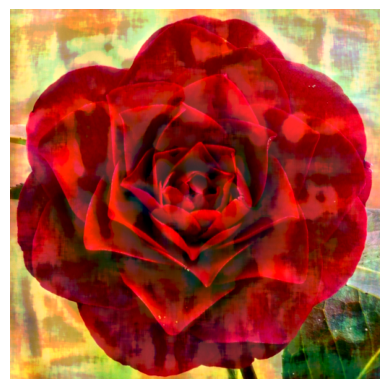

In [57]:
plt.axis("off")
plt.imshow((patch).transpose(1,2,0).astype(np.uint8))

Loss by component and per batch

x and y must have same first dimension, but have shapes (0,) and (1,)


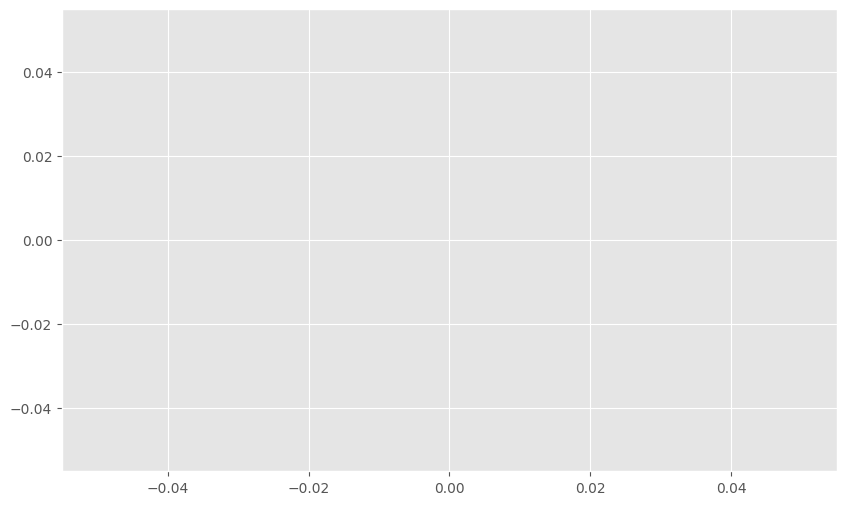

In [58]:
try:
    # Calculate the sum of both losses
    total_losses = [d + c for d, c in zip((i * disguise_distance_factor for i in ap.detailed_loss_history["disguise"]), ap.detailed_loss_history["classification"])]

    # Create steps for x-axis
    steps = list(range(1, len(total_losses) + 1))

    plt.figure(figsize=(10, 6))

    # Plot the three lines
    plt.plot(steps, [i * disguise_distance_factor for i in  ap.detailed_loss_history["disguise"]], 'b-', linewidth=2, label='Disguise Loss')
    plt.plot(steps, ap.detailed_loss_history["classification"], 'g-', linewidth=2, label='Classification Loss')
    plt.plot(steps, total_losses, 'r-', linewidth=2.5, label='Total Loss')

    plt.xlabel('Training Step')
    plt.ylabel('Loss Value')
    plt.title('Loss History Comparison')

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()

    plt.show()

    # If you want to save the figure
    # plt.savefig('loss_history.png', dpi=300, bbox_inches='tight')
except Exception as e:
    print(e)

# Validation

Set seed for validation

In [59]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)


Validation of the trained patch:

In [60]:
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"GPU memory cached: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

GPU memory allocated: 0.10 GB
GPU memory cached: 14.47 GB


In [61]:
torch.cuda.empty_cache()

In [ ]:
%matplotlib inline

# load external patch
# patch=np.array(Image.open("patch_apple_v5.png")) # 
# patch = patch.transpose(2,0,1)

classes = ["stop sign", "banana", "person", "car", "truck", "traffic light"] # the classes we want to have shown in the plots
n_boxes = 60 # max number of boxes to plot
colordict =  {"stop sign":(255, 0, 0), "banana": (0,0,255), "car":(200, 0, 200), "person":(0, 200, 200)}
plot_threshold = 0.2
SCALE = scale_max - (scale_max - scale_min)/2 # take the middle of the scale range
SKIP = 0
TRY_HALF_PATCH = True
PLOT_N_SAMPLES = 1
SHOW_IMAGES = False

DEBUG = False


detector = create_detector_model()

detector.model.eval()

def load_and_transform_image(url):
    im = Image.open(url)
    return transform(im).numpy()

def batch_predict(urls, batch_size):
    all_predictions = []
    for i in tqdm(range(0, len(urls), batch_size), desc="predict"):
        batch_urls = urls[i:i + batch_size]
        batch_images = np.array([load_and_transform_image(url) for url in batch_urls])*255
        batch_dets = detector.predict(batch_images)
        all_predictions.extend(batch_dets)
    return all_predictions

def get_images(urls):
    images = np.array([load_and_transform_image(url) for url in urls])*255
    return images

def batch_predict_raw(imgs, batch_size=1):
    all_predictions = []
    for i in range(0, len(imgs), batch_size):
        batch_imgs = imgs[i:i + batch_size]
        batch_dets = detector.predict(batch_imgs)
        all_predictions.extend(batch_dets)
    return all_predictions

def rectangles_overlap(box1, box2):
    """
    Check if two rectangles overlap.
    Args:
        box1: tuple of (x1, y1, x2, y2) or ((x1, y1), (x2, y2))
        box2: tuple of (x1, y1, x2, y2)
    """
    # Handle different input formats
    if len(box1) == 2 and isinstance(box1[0], tuple):
        # Format: ((x1, y1), (x2, y2))
        x1_1, y1_1 = box1[0]
        x2_1, y2_1 = box1[1]
    else:
        # Format: (x1, y1, x2, y2)
        x1_1, y1_1, x2_1, y2_1 = box1

    x1_2, y1_2, x2_2, y2_2 = box2
    print(x1_1, y1_1, x2_1, y2_1, "___", x1_2, y1_2, x2_2, y2_2)

    if x2_1 <= x1_2 or x2_2 <= x1_1 or y2_1 <= y1_2 or y2_2 <= y1_1:
        print("\nFalse\n")
        return False
    return True

def overlapping(preds, target):
    """
    Filter predictions to keep only those that overlap with the target box
    That way we remove any detections of real stop signs or false positives that are not caused by a patch
    """

    labels, boxes, scores = preds

    filtered_labels = []
    filtered_boxes = []
    filtered_scores = []

    # Check each prediction box against all target boxes
    for j, pred_box in enumerate(boxes):
        if rectangles_overlap(pred_box, target):
            filtered_labels.append(labels[j])
            filtered_boxes.append(pred_box)
            filtered_scores.append(scores[j])

    return (filtered_labels, filtered_boxes, filtered_scores)



cut_urls = validation_urls[:DATASET_CUTOFF if DATASET_CUTOFF>0 and DATASET_CUTOFF<=len(urls) else len(urls)]
#sampled_urls = random.sample(cut_urls, PLOT_N_SAMPLES if PLOT_N_SAMPLES > 0 and PLOT_N_SAMPLES <= len(cut_urls) else len(cut_urls))
show_indices = set(random.sample(range(len(cut_urls) + 1), PLOT_N_SAMPLES))

set_seed()
dets_orig = batch_predict(cut_urls, batch_size)
preds_orig_person = [extract_predictions(dets, plot_threshold, n_boxes=n_boxes, classes=["person"]) for dets in dets_orig]

number_of_attacks = 0
successful_attacks = 0
successful_attacks_l = 0
successful_attacks_r = 0
success_threshold = 0.5

all_stop_sign_scores_patch = []

for j in tqdm(range(len(cut_urls)), desc="val steps"):
    training_images = get_images(cut_urls[j:j+1])

    if split:
        if TRY_HALF_PATCH:
            patched_images_l, target_boxes_l = ap.apply_patch(training_images[:], scale=SCALE, patch_external=patch, split=split, split_keep_both=False, half_to_keep="left", return_patch_outlines=True, patch_locations=preds_orig_person[j:j+1])
            dets_l = batch_predict_raw(patched_images_l)
            #dets_l = detector.predict(patched_images_l)

            patched_images_r, target_boxes_r = ap.apply_patch(training_images[:], scale=SCALE, patch_external=patch, split=split, split_keep_both=False, half_to_keep="right", return_patch_outlines=True, patch_locations=preds_orig_person[j:j+1])
            dets_r = batch_predict_raw(patched_images_r)
            #dets_r = detector.predict(patched_images_r)

        set_seed()
        patched_images, target_boxes = ap.apply_patch(training_images[:], scale=SCALE, patch_external=patch, split=split, split_keep_both=True, return_patch_outlines=True, patch_locations=preds_orig_person[j:j+1]) # , locations =
    else:
        set_seed()
        patched_images, target_boxes = ap.apply_patch(training_images[:], scale=SCALE, patch_external=patch, split=split, split_keep_both=True, return_patch_outlines=True, patch_locations=preds_orig_person[j:j+1])

    set_seed()
    dets = batch_predict_raw(patched_images)


    for i in range(len(dets)):
        SHOW_IMAGES = True
        if j in show_indices:
            SHOW_IMAGES = True

        number_of_attacks += 1
        if i<SKIP:
            continue
        preds_orig = extract_predictions(dets_orig[i], plot_threshold, n_boxes=n_boxes, classes=classes)

        preds = extract_predictions(dets[i], plot_threshold, n_boxes=n_boxes, classes=classes)
        preds_stop_sign = extract_predictions(dets[i], success_threshold, n_boxes=n_boxes, classes=["stop sign"])

        overlapping_stop_sign_preds = overlapping(preds_stop_sign, target_boxes[i])

        if split and TRY_HALF_PATCH:
            preds_l = extract_predictions(dets_l[i], plot_threshold, n_boxes=n_boxes, classes=classes)
            preds_r = extract_predictions(dets_r[i], plot_threshold, n_boxes=n_boxes, classes=classes)
            preds_stop_sign_l = extract_predictions(dets_l[i], success_threshold, n_boxes=n_boxes, classes=["stop sign"])
            preds_stop_sign_r = extract_predictions(dets_r[i], success_threshold, n_boxes=n_boxes, classes=["stop sign"])
            overlapping_stop_sign_preds_l = overlapping(preds_stop_sign_l, target_boxes[i])
            overlapping_stop_sign_preds_r = overlapping(preds_stop_sign_r, target_boxes[i])
            if overlapping_stop_sign_preds_l[0]:
                successful_attacks_l += 1
            if overlapping_stop_sign_preds_r[0]:
                successful_attacks_r += 1


        preds_stop_sign = overlapping_stop_sign_preds
        #preds = preds_stop_sign # NOTE uncomment this line to only see detections that overlap the patch location, e.g. are counted for the ASR

        if preds_stop_sign[2]:
            all_stop_sign_scores_patch.append(preds_stop_sign[2][0]) # index 2 is all scores, 0 taking the first

        if preds_stop_sign[0]:
            successful_attacks += 1

        if SHOW_IMAGES:
            plot_image_with_boxes(img=patched_images[i].transpose(1,2,0).copy(), boxes=preds[1], pred_cls=preds[0], target_boxes=target_boxes[i],
                                title=f"Predictions on image with both halves patch", scores=preds[2], colordict=colordict)
        if split and TRY_HALF_PATCH:
            preds = extract_predictions(dets_l[i], plot_threshold, n_boxes=n_boxes, classes=classes)
            plot_image_with_boxes(img=patched_images_l[i].transpose(1,2,0).copy(), boxes=preds_l[1], pred_cls=preds_l[0], target_boxes=target_boxes_l[i],
                                    title="Predictions on image with left half of patch", scores=preds_l[2], colordict=colordict)
            preds = extract_predictions(dets_r[i], plot_threshold, n_boxes=n_boxes, classes=classes)
            plot_image_with_boxes(img=patched_images_r[i].transpose(1,2,0).copy(), boxes=preds_r[1], pred_cls=preds_r[0], target_boxes=target_boxes_r[i],
                                    title="Predictions on image with right half of patch", scores=preds_r[2], colordict=colordict)

print(successful_attacks)

val steps:   0%|          | 0/304 [00:00<?, ?it/s]


TypeError: AdversarialPatchPyTorch.apply_patch() got an unexpected keyword argument 'scale_max'

In [ ]:
torch.cuda.empty_cache()

In [ ]:
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"GPU memory cached: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

GPU memory allocated: 0.10 GB
GPU memory cached: 0.55 GB


In [ ]:
torch.cuda.empty_cache()

Comparison to using the original disguise:



In [ ]:
%matplotlib inline

if DISGUISE_PATH is not None:
    disguise_patch=np.array(Image.open(DISGUISE_PATH)) # load external patch
    disguise_patch = disguise_patch.transpose(2,0,1)

    set_seed()
    dets_orig = batch_predict(cut_urls, batch_size)
    preds_orig_person = [extract_predictions(dets, plot_threshold, n_boxes=n_boxes, classes=["person"]) for dets in dets_orig]

    number_of_attacks_disguise = 0
    successful_attacks_disguise = 0

    all_stop_sign_scores_disguise = []

    DEBUG = False

    for j in tqdm(range(len(cut_urls)), desc="val steps"):
        training_images = get_images(cut_urls[j:j+1])

        if split:
            if TRY_HALF_PATCH:
                patched_images_l, target_boxes_l = ap.apply_patch(training_images[:], scale=SCALE, patch_external=disguise_patch, split=split, split_keep_both=False, half_to_keep="left", return_patch_outlines=True, patch_locations=preds_orig_person[j:j+1])
                dets_l = batch_predict_raw(patched_images_l)
                #dets_l = detector.predict(patched_images_l)

                patched_images_r, target_boxes_r = ap.apply_patch(training_images[:], scale=SCALE, patch_external=disguise_patch, split=split, split_keep_both=False, half_to_keep="right", return_patch_outlines=True, patch_locations=preds_orig_person[j:j+1])
                dets_r = batch_predict_raw(patched_images_r)
                #dets_r = detector.predict(patched_images_r)


            if DEBUG: print("\n\n\n")
            set_seed()
            patched_images, target_boxes = ap.apply_patch(training_images[:], scale=SCALE, patch_external=disguise_patch, split=split, split_keep_both=True, return_patch_outlines=True, patch_locations=preds_orig_person[j:j+1]) # , locations =
        else:
            set_seed()
            patched_images, target_boxes = ap.apply_patch(training_images[:], scale_max=scale_max, scale_min=scale_min, patch_external=disguise_patch, split=split, split_keep_both=True, return_patch_outlines=True, patch_locations=preds_orig_person[j:j+1])

        set_seed()
        dets = batch_predict_raw(patched_images)


        for i in range(len(dets)):
            SHOW_IMAGES = True
            if j in show_indices:
                SHOW_IMAGES = True

            number_of_attacks_disguise += 1
            if i<SKIP:
                continue
            preds_orig = extract_predictions(dets_orig[i], plot_threshold, n_boxes=n_boxes, classes=classes)

            preds = extract_predictions(dets[i], plot_threshold, n_boxes=n_boxes, classes=classes)
            preds_stop_sign = extract_predictions(dets[i], success_threshold, n_boxes=n_boxes, classes=["stop sign"])

            overlapping_stop_sign_preds = overlapping(preds_stop_sign, target_boxes[i])

            if preds_stop_sign != overlapping_stop_sign_preds:
                print("\n_________\nbefore")
                print(preds_stop_sign)
                print("after")
                print(preds_stop_sign)
                print("target")
                print(target_boxes[i])
            preds_stop_sign = overlapping_stop_sign_preds
            preds = preds_stop_sign # TODO TEMP REMOVE

            if preds_stop_sign[2]:
                all_stop_sign_scores_disguise.append(preds_stop_sign[2][0]) # index 2 is all scores, 0 taking the first

            if preds_stop_sign[0]:
                successful_attacks_disguise += 1

            if DEBUG: print("preds_stop_sign", preds_stop_sign)
            if SHOW_IMAGES:
                plot_image_with_boxes(img=patched_images[i].transpose(1,2,0).copy(), boxes=preds[1], pred_cls=preds[0], target_boxes=target_boxes[i],
                                    title=f"Predictions on image with both halves patch", scores=preds[2], colordict=colordict)



In [ ]:
print(len(all_stop_sign_scores_patch))
if DISGUISE_PATH is not None: 
    print(len(all_stop_sign_scores_disguise))


127


In [ ]:
print("========================")
print("STATS for adversarial PATCH")
print("threshold", success_threshold)
print("Number of attacks:", number_of_attacks)
print("Successful attacks:", successful_attacks)
print("Success rate:", successful_attacks/number_of_attacks)

if DISGUISE_PATH is not None:
    print("========================")
    print("STATS for DISGUISE")
    print("threshold", success_threshold)
    print("Number of attacks:", number_of_attacks_disguise)
    print("Successful attacks:", successful_attacks_disguise)
    print("Success rate:", successful_attacks_disguise/number_of_attacks_disguise)

if split and TRY_HALF_PATCH:
    print("========================")
    print("STATS for HALF PATCHES")
    print("Successful attacks left:", successful_attacks_l)
    print("Successful attacks right:", successful_attacks_r)
    print("Success rate left:", successful_attacks_l/number_of_attacks)
    print("Success rate right:", successful_attacks_r/number_of_attacks)

STATS for adversarial PATCH
threshold 0.5
Number of attacks: 304
Successful attacks: 127
Success rate: 0.41776315789473684


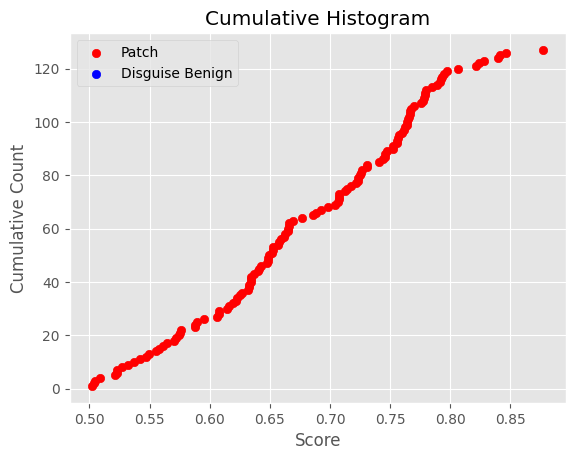

In [ ]:


def cumulative_histogram(red_points, blue_points):
    # Plot the cumulative histogram
    red_points.sort()
    blue_points.sort()

    all_stop_sign_scores_x = []
    all_stop_sign_scores_y = []
    count = 0
    for s in red_points:
        count += 1
        all_stop_sign_scores_x.append(s)
        all_stop_sign_scores_y.append(count)

    all_stop_sign_scores_x_b = []
    all_stop_sign_scores_y_b = []
    count_b = 0
    for s in blue_points:
        count_b += 1
        all_stop_sign_scores_x_b.append(s)
        all_stop_sign_scores_y_b.append(count_b)

    plt.scatter(all_stop_sign_scores_x, all_stop_sign_scores_y, color="red", label="Patch" )
    plt.scatter(all_stop_sign_scores_x_b, all_stop_sign_scores_y_b, color="blue", label="Disguise Benign" )
    plt.legend()
    plt.xlabel('Score')
    plt.ylabel('Cumulative Count')
    plt.title('Cumulative Histogram')
    plt.grid(True)
    plt.show()



cumulative_histogram(all_stop_sign_scores_patch, all_stop_sign_scores_disguise if DISGUISE_PATH is not None else [])


Check the Perturbation applied to the starting image:

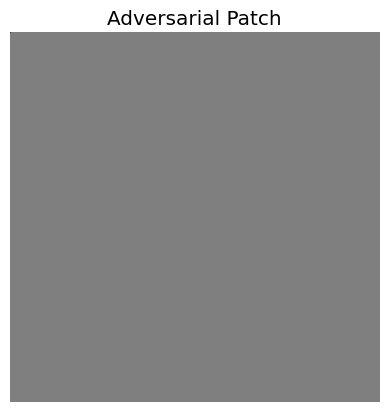

In [ ]:
def show_image(tensor, title=""):
    to_pil = transforms.ToPILImage()
    tensor = np.abs(tensor)
    tensor[:, 0, 0] = (0, 0, 0)
    tensor[:, 0, 1] = (255, 0, 255)
    img = to_pil(tensor.transpose(1,2,0))

    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()


show_image(ap._patch.cpu().detach().numpy().astype(np.uint8), title="Adversarial Patch")
if DISGUISE_PATH is not None:
    show_image(disguise_patch.astype(np.uint8), title="Disguise")
    temp = ap._patch.cpu().detach().numpy().astype(np.int16) - disguise_patch.astype(np.int16)
    temp = np.clip(temp + 128, 0, 255).astype(np.uint8)
    show_image(temp, title="Adversarial Perturbation")